In [13]:
# Computer Vision Course (CSE 40535)
# Practical 4: Deep learning-based object recognition
# University of Notre Dame
# ________________________________________________
# Adam Czajka, Siamul Khan, Arturo Russell 2019-2025

# Step 1: Prerequisities (installing libraries and tools we will use today)

In [15]:
# Two lines below (when uncommented) allow you to track the time spent on each cell, if you wanted
# !pip install ipython-autotime
# %load_ext autotime

import cv2
import os
import sys
import numpy as np
from sklearn import svm
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
import torchvision.datasets as datasets
from torchvision.transforms import Compose, Resize
import tensorflow as tf

In [17]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from base64 import b64decode, b64encode
import PIL
import io

# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

#@title Webcam live streaming code (just run it)
# JavaScript to properly create our live video stream using our webcam as input
def video_stream():
  js = Javascript('''
    var video;
    var div = null;
    var stream;
    var captureCanvas;
    var imgElement;
    var labelElement;

    var pendingResolve = null;
    var shutdown = false;

    function removeDom() {
       stream.getVideoTracks()[0].stop();
       video.remove();
       div.remove();
       video = null;
       div = null;
       stream = null;
       imgElement = null;
       captureCanvas = null;
       labelElement = null;
    }

    function onAnimationFrame() {
      if (!shutdown) {
        window.requestAnimationFrame(onAnimationFrame);
      }
      if (pendingResolve) {
        var result = "";
        if (!shutdown) {
          captureCanvas.getContext('2d').drawImage(video, 0, 0, 640, 480);
          result = captureCanvas.toDataURL('image/jpeg', 0.8)
        }
        var lp = pendingResolve;
        pendingResolve = null;
        lp(result);
      }
    }

    async function createDom() {
      if (div !== null) {
        return stream;
      }

      div = document.createElement('div');
      div.style.border = '2px solid black';
      div.style.padding = '3px';
      div.style.width = '100%';
      div.style.maxWidth = '600px';
      document.body.appendChild(div);

      const modelOut = document.createElement('div');
      modelOut.innerHTML = "<span>Status:</span>";
      labelElement = document.createElement('span');
      labelElement.innerText = 'No data';
      labelElement.style.fontWeight = 'bold';
      modelOut.appendChild(labelElement);
      div.appendChild(modelOut);

      video = document.createElement('video');
      video.style.display = 'block';
      video.width = div.clientWidth - 6;
      video.setAttribute('playsinline', '');
      video.onclick = () => { shutdown = true; };
      stream = await navigator.mediaDevices.getUserMedia(
          {video: { facingMode: "environment"}});
      div.appendChild(video);

      imgElement = document.createElement('img');
      imgElement.style.position = 'absolute';
      imgElement.style.zIndex = 1;
      imgElement.onclick = () => { shutdown = true; };
      div.appendChild(imgElement);

      const instruction = document.createElement('div');
      instruction.innerHTML =
          '<span style="color: red; font-weight: bold;">' +
          'When finished, click here or on the video to stop this demo</span>';
      div.appendChild(instruction);
      instruction.onclick = () => { shutdown = true; };

      video.srcObject = stream;
      await video.play();

      captureCanvas = document.createElement('canvas');
      captureCanvas.width = 640; //video.videoWidth;
      captureCanvas.height = 480; //video.videoHeight;
      window.requestAnimationFrame(onAnimationFrame);

      return stream;
    }
    async function stream_frame(label, imgData) {
      if (shutdown) {
        removeDom();
        shutdown = false;
        return '';
      }

      var preCreate = Date.now();
      stream = await createDom();

      var preShow = Date.now();
      if (label != "") {
        labelElement.innerHTML = label;
      }

      if (imgData != "") {
        var videoRect = video.getClientRects()[0];
        imgElement.style.top = videoRect.top + "px";
        imgElement.style.left = videoRect.left + "px";
        imgElement.style.width = videoRect.width + "px";
        imgElement.style.height = videoRect.height + "px";
        imgElement.src = imgData;
      }

      var preCapture = Date.now();
      var result = await new Promise(function(resolve, reject) {
        pendingResolve = resolve;
      });
      shutdown = false;

      return {'create': preShow - preCreate,
              'show': preCapture - preShow,
              'capture': Date.now() - preCapture,
              'img': result};
    }
    ''')

  display(js)


def video_frame(label, bbox):
  data = eval_js('stream_frame("{}", "{}")'.format(label, bbox))
  return data


# Step 2: Choosing and loading the CNN-based feature extractor

In [22]:
# We are utilizing Keras API to load the pretrained VGG16 model as our feature extractor for training SVM
model = VGG16(weights='imagenet')

# *** TASK 3:
# Choose the layer of the VGG model used to get your features (= "network embeddings")
cnn_codes = 'fc1'

# Loading our model that will output the network enbeddings specified by us above (instead of a classification decision)
features_model = Model(inputs=model.input, outputs=model.get_layer(cnn_codes).output)

# And here is the function that will give us VGG-based features for an image "img"
def extract_vgg_features(img):
    # prepare the image for VGG
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_LINEAR)
    img = img[np.newaxis, :, :, :]
    # call feature extraction
    return features_model.predict(img,verbose=0)

# Step 3: Downloading a training dataset to train our SVM classifier

Now we need a dataset, which contains example images of the objects you brought to the class today (so that we can extract VGG16 features for our required objects and use these as a training dataset for our SVM).

We choose the Caltech101 dataset which consists of pictures of objects belonging to 101 classes, plus one background clutter class. Each image is labelled with a single object. Each class contains roughly 40 to 800 images, totalling around 9k images. Images are of variable sizes, with typical edge lengths of 200-300 pixels.

You can read more about it in: https://data.caltech.edu/records/mzrjq-6wc02

In [23]:
# Let's download and extract the Caltech101 dataset.
!wget -c https://notredame.box.com/shared/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz -O caltech101.tar.gz
%mkdir ./caltech101/
!tar -zxf caltech101.tar.gz -C ./caltech101/

# We need to convert PIL images in to OpenCV images
class ToCV2(object):

    def __call__(self, sample):
        #image, label = sample['image'], sample['label']

        image = np.array(sample.convert('RGB'))
        image = image[:, :, ::-1].copy()

        return image

caltech101_dataset = datasets.Caltech101(root='./', transform=Compose([Resize((224, 224)), ToCV2()]))

--2026-04-04 18:31:26--  https://notredame.box.com/shared/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz
Resolving notredame.box.com (notredame.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to notredame.box.com (notredame.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz [following]
--2026-04-04 18:31:26--  https://notredame.box.com/public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz
Reusing existing connection to notredame.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://notredame.app.box.com/public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz [following]
--2026-04-04 18:31:26--  https://notredame.app.box.com/public/static/o5hw6ljq7x00smui4ixo9akxwlq2dkib.gz
Resolving notredame.app.box.com (notredame.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to notredame.app.box.com (notredame.app.box.com)|74.112.186.1

# Step 4: Extracting features (VGG network embeddings) for training samples. These embeddings will serve as the input to the SVM classifier.

In [24]:
# First, let us find the label numbers for our objects

# *** TASK 1 and TASK 2:
#  We are going to use this list to restrict the objets our classifier will recognize
my_object_list = ['umbrella','headphone','scissors', "Leopards", "Motorbikes", "airplanes", "bonsai", "crayfish",  "dollar_bill", "kangaroo"]

my_object_label_list = []
for my_object in my_object_list:
    for i, category in enumerate(caltech101_dataset.categories):
        if category == my_object:
            my_object_label_list.append(i)
print("{} -> {} (class indicies in CALTECH101)".format(my_object_list,my_object_label_list))

map_id2name = {}
for id,name in zip(my_object_label_list,my_object_list):
  map_id2name[id]=name


['umbrella', 'headphone', 'scissors', 'Leopards', 'Motorbikes', 'airplanes', 'bonsai', 'crayfish', 'dollar_bill', 'kangaroo'] -> [93, 48, 80, 2, 3, 5, 12, 27, 32, 54] (class indicies in CALTECH101)


In [25]:
# Split data into train and validation
from tqdm import tqdm
from sklearn.model_selection import train_test_split

c101_images = []
c101_labels = []

# We can load the entire dataset on RAM as the dataset is pretty small
print("Loading dataset to RAM....")
for image, label in tqdm(caltech101_dataset):
    if int(label) in my_object_label_list:
        c101_images.append(image)
        c101_labels.append(int(label))

X_train, X_val, y_train, y_val = train_test_split(
    np.array(c101_images), np.array(c101_labels),
    test_size=0.2,
    random_state=42
)

print(len(X_train), len(X_val))

Loading dataset to RAM....


100%|██████████| 8677/8677 [00:24<00:00, 356.10it/s]


1832 458


In [26]:
# Next, let's extract the VGG features required for our selected object categories.
# It should take no longer than 5 minutes.

from tqdm import tqdm

batch_size = 128

print('Extracting features.....')
# Now we convert the images into vgg features
c101_vgg_features_train = features_model.predict(np.array(X_train), batch_size=batch_size, verbose=1)
c101_vgg_features_val = features_model.predict(np.array(X_val), batch_size=batch_size, verbose=1)

assert len(c101_vgg_features_train) == len(y_train)
assert len(c101_vgg_features_val) == len(y_val)

Extracting features.....
15/15 ━━━━━━━━━━━━━━━━━━━━ 944s 62s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 239s 58s/step


# Step 5: We are finally ready to train our SVM, let's do this!

In [45]:
# Training SVM classifier

# *** TASK 1 and 3
clf = svm.SVC(kernel='poly').fit(c101_vgg_features_train, y_train)


# Step 6: Analyze your classifer's accuracy!

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
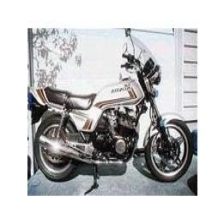

In [46]:
# select a sample from your validation set
val_sample = X_val[23]
val_sample

In [47]:
# classify your validation sample
features = extract_vgg_features(val_sample)
pred = clf.predict(features)
print(map_id2name[pred[0]])

Motorbikes


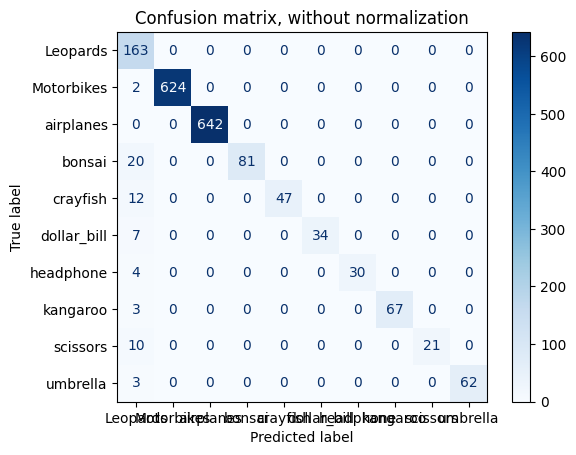

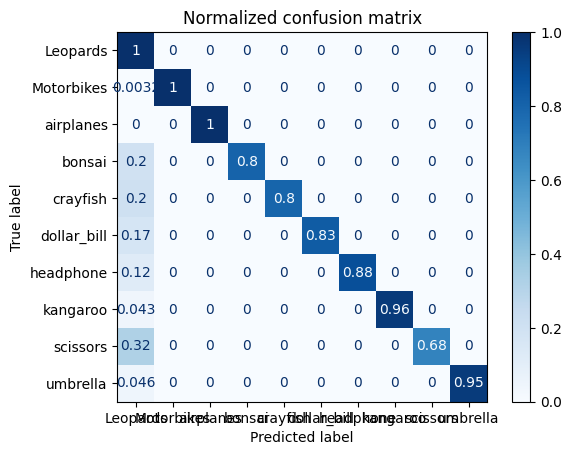

In [48]:
# plot the confusion matrix for the training data
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = []
for id_ in clf.classes_:
  class_names.append(map_id2name[id_])

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        clf,
        c101_vgg_features_train,
        y_train,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

plt.show()

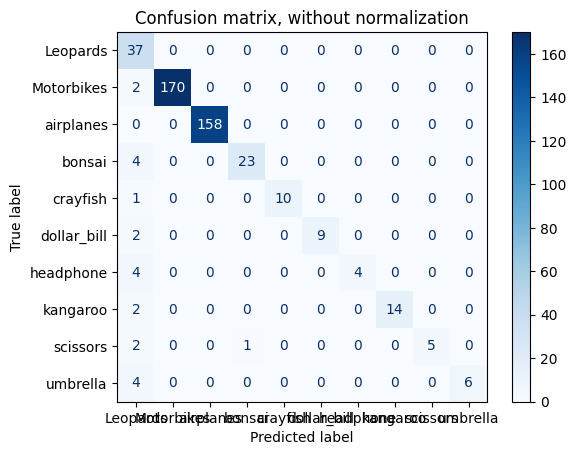

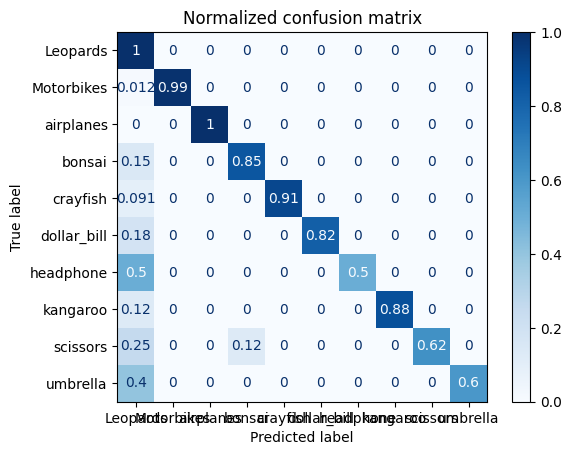

In [49]:
# plot the confusion matrix for the validation data
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = []
for id_ in clf.classes_:
  class_names.append(map_id2name[id_])

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
values = []
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        clf,
        c101_vgg_features_val,
        y_val,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)
    values.append(disp.confusion_matrix)

plt.show()

In [50]:
# *** Task 1
# Compute the accuracy of your model here (total accuracy and per-class accuracy)
# HINT: Use the values variable
print(f'total accuracy: {np.trace(values[0])/np.sum(values[0])*100:.4f}%')

print("Per-class accuarcy")
for i in range(values[0].shape[0]):
  print(f'{class_names[i]} accuracy: {values[0][i][i]/np.sum(values[0][i])*100:.4f}%')

total accuracy: 95.1965%
Per-class accuarcy
Leopards accuracy: 100.0000%
Motorbikes accuracy: 98.8372%
airplanes accuracy: 100.0000%
bonsai accuracy: 85.1852%
crayfish accuracy: 90.9091%
dollar_bill accuracy: 81.8182%
headphone accuracy: 50.0000%
kangaroo accuracy: 87.5000%
scissors accuracy: 62.5000%
umbrella accuracy: 60.0000%


# Step 7: Test your classifier!

In [20]:
# Now, let's see how our trained SVM processes the webcam stream
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

video_stream()

# label for video
label_html = 'Capturing...'

# initialze bounding box to empty string
svm_overlay = ''
count = 0

while True:
    js_reply = video_frame(label_html, svm_overlay)
    if not js_reply:
        break

    # convert JS response to OpenCV image
    frame = js_to_image(js_reply["img"])

    # create transparent overlay for svm classification info
    svm_overlay = np.zeros([480,640,4], dtype=np.uint8)

    features = extract_vgg_features(frame)
    pred = clf.predict(features)

    # show the classification result
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(svm_overlay, '{}'.format(caltech101_dataset.categories[pred[0]]), (15, 25), font, 1, (0, 255, 0), 2, cv2.LINE_AA)

    svm_overlay[:,:,3] = (svm_overlay.max(axis = 2) > 0 ).astype(int) * 255
    # convert overlay of bbox into bytes
    svm_overlay = to_bytes(svm_overlay)


<IPython.core.display.Javascript object>

# Task 2